# Reviewer-Response Analysis — Physical Realizability of Partial Mueller Matrices

This notebook implements the quantitative analyses requested by the co-author's review.
Each section is mapped to a specific comment, states the question, runs the analysis, and
prints a one-line conclusion you can paste into the response letter.

| § | Reviewer comment | What this notebook does |
|---|------------------|--------------------------|
| 1 | Setup | Load models + simulated phantoms, compute CCP ground truth |
| 2 | **#5** "Perfect 1.0 is unusual" | Class balance + majority baseline + *full* metrics (balanced acc, MCC) to test whether 1.0 is trivial |
| 3 | **#4** "XGBoost 0.91 vs 1.0 → overfitting to tissue" | Confusion direction + feature importance + per-thickness stability |
| 4 | **#3** "No noise sensitivity (±5–20%)" | Gaussian noise sweep, all 3 models, multiple seeds |
| 5 | **#3** "No confidence intervals" | Bootstrap CIs (+ caveat on pixel correlation) |
| 6 | **#6** "Are errors clustered or scattered?" | Spatial error maps + clustering statistic |
| 7 | **#1** "Can PR be uniquely determined from partial MM?" | Empirical label-collision / neighbourhood-purity test |
| 8 | **#5** "Compare real vs simulated distributions (Wasserstein)" | Per-element Wasserstein (auto-skips if real data not mounted) |
| 9 | Summary | Collated table for the rebuttal |

**Note on data availability.** The simulated phantom data ships in the repo, so §2–§7 run
out of the box. §6 (real tissue) and §8 require the real-tissue test images on the external
SSD; those cells auto-detect the data and skip cleanly with a message if it is not mounted.


## 1. Setup: imports, models, ground truth

In [1]:
import os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import xgboost as xgb
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             balanced_accuracy_score, matthews_corrcoef, confusion_matrix)
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore")
torch.set_num_threads(1)  # avoid OpenMP issues in Jupyter on macOS
rng = np.random.default_rng(42)

# locate project root (folder containing src/)
project_root = None
for root in [Path.cwd(), *Path.cwd().parents]:
    if (root / "src").exists():
        project_root = root
        break
assert project_root is not None, "Could not find project root containing src/"
sys.path.insert(0, str(project_root))
print("Project root:", project_root)

from src.utils.file_paths import file_paths, TISSUE_DIMENSIONS
from src.utils.physical_realizability import charpoly_vectorized

OUT_DIR = project_root / "results" / "reviewer_response"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Figures/tables ->", OUT_DIR)


Project root: /Users/chaechae/Desktop/EP_Code/partialPr
Figures/tables -> /Users/chaechae/Desktop/EP_Code/partialPr/results/reviewer_response


In [2]:
class PixelMLP(nn.Module):
    """MLP matching the saved checkpoints (Linear-BatchNorm-ReLU-Dropout blocks)."""
    def __init__(self, input_dim=12, hidden_dims=(128, 64, 32), dropout_rate=0.30):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_rate)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# scenario -> model files + element selector from a (...,4,4) array
SCENARIOS = {
    "3x3": dict(xgb="pixel_xgb_3x3.json", mlp="best_pixel_mlp_3x3.pth",
                cat="pixel_catboost_3x3.cbm", sel=lambda M: M[..., :3, :3]),
    "3x4": dict(xgb="pixel_xgb.json", mlp="best_pixel_mlp.pth",
                cat="pixel_catboost.cbm", sel=lambda M: M[..., :3, :]),
    "4x3": dict(xgb="pixel_xgb_4x3.json", mlp="best_pixel_mlp_4x3.pth",
                cat="pixel_catboost_4x3.cbm", sel=lambda M: M[..., :, :3]),
}

def extract_features(mm_hw16, scenario):
    """(H,W,16) -> (N, n_feat) feature matrix for the given scenario."""
    H, W, _ = mm_hw16.shape
    M44 = mm_hw16.reshape(H, W, 4, 4)
    return SCENARIOS[scenario]["sel"](M44).reshape(H * W, -1)

def load_models(scenario):
    cfg = SCENARIOS[scenario]
    mp = file_paths.model_save_path
    models = {}
    # XGBoost
    bst = xgb.Booster(); bst.load_model(str(mp / cfg["xgb"])); models["XGBoost"] = bst
    # CatBoost
    cb = CatBoostClassifier(); cb.load_model(str(mp / cfg["cat"])); models["CatBoost"] = cb
    # MLP
    n_feat = {"3x3": 9, "3x4": 12, "4x3": 12}[scenario]
    mlp = PixelMLP(input_dim=n_feat).to(DEVICE)
    mlp.load_state_dict(torch.load(mp / cfg["mlp"], map_location=DEVICE, weights_only=False))
    mlp.eval(); models["MLP"] = mlp
    return models

def predict_proba(models, X, threshold=0.5, batch=200000):
    """Return dict model -> (probs, preds). X is (N, n_feat) float."""
    X = np.asarray(X, dtype=np.float32)
    out = {}
    # XGBoost
    out["XGBoost"] = models["XGBoost"].predict(xgb.DMatrix(X, nthread=1))
    # CatBoost
    out["CatBoost"] = models["CatBoost"].predict_proba(X)[:, 1]
    # MLP
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = torch.tensor(X[i:i+batch], dtype=torch.float32, device=DEVICE)
            probs.append(torch.sigmoid(models["MLP"](xb)).cpu().numpy().ravel())
    out["MLP"] = np.concatenate(probs) if probs else np.array([])
    return {m: (p, (p > threshold).astype(int)) for m, p in out.items()}

def metric_row(y_true, y_pred):
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        balanced_acc=balanced_accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, zero_division=0),
        recall=recall_score(y_true, y_pred, zero_division=0),
        f1=f1_score(y_true, y_pred, zero_division=0),
        mcc=matthews_corrcoef(y_true, y_pred),
    )
print("Helpers ready. Device:", DEVICE)


Helpers ready. Device: cpu


In [3]:
def normalize_by_m11(mm_hw16):
    m11 = mm_hw16[:, :, 0:1].copy()
    m11[m11 == 0] = 1e-12
    return mm_hw16 / m11

def ground_truth_pr(mm_hw16, batch=50000):
    H, W, _ = mm_hw16.shape
    M = mm_hw16.reshape(-1, 4, 4)
    out = np.zeros(len(M), dtype=bool)
    for i in range(0, len(M), batch):
        out[i:i+batch] = charpoly_vectorized(M[i:i+batch])
    return out.reshape(H, W)

# Load simulated phantoms
SIM_FILES = {"225um": "mm_225um_raw.npy", "250um": "mm_250um_raw.npy", "300um": "mm_300um_raw.npy"}
sim_path = file_paths.simulated_test_path
phantoms = {}
for name, fn in SIM_FILES.items():
    raw = np.load(sim_path / fn)          # (H,W,16)
    norm = normalize_by_m11(raw)
    gt = ground_truth_pr(norm)            # (H,W) bool, CCP on full 4x4
    phantoms[name] = dict(raw=raw, norm=norm, gt=gt)
    print(f"{name}: shape={raw.shape}, PR fraction (GT) = {gt.mean():.4f}")


225um: shape=(100, 100, 16), PR fraction (GT) = 0.1976
250um: shape=(100, 100, 16), PR fraction (GT) = 0.1976
300um: shape=(100, 100, 16), PR fraction (GT) = 0.1976


## 2. Reviewer #5 — Is the "perfect 1.0" actually informative?

The reviewer flags 1.0 accuracy as suspicious. The decisive test is the **class balance**:
if a phantom is (nearly) all-PR, then a trivial "always predict PR" classifier also scores
~1.0, so accuracy is uninformative. We therefore report, per phantom and per model:

- the **majority-class baseline** accuracy (predict the dominant class everywhere), and
- **balanced accuracy** and **MCC**, which collapse to ~0.5 / ~0 for a trivial classifier.

If balanced accuracy and MCC are high *and* the class balance is non-trivial, 1.0 is real.
If the set is ~all-PR, we should stop reporting bare accuracy and say so.


In [4]:
SCENARIO = "3x4"   # the deployment-relevant input; switch to "3x3" to mirror the sim table
models = load_models(SCENARIO)

rows = []
for name, d in phantoms.items():
    y = d["gt"].ravel().astype(int)
    pr_frac = y.mean()
    maj_baseline = max(pr_frac, 1 - pr_frac)   # accuracy of always-predict-majority
    X = extract_features(d["norm"], SCENARIO)
    preds = predict_proba(models, X)
    for model, (probs, yhat) in preds.items():
        r = metric_row(y, yhat)
        r.update(phantom=name, model=model, PR_fraction=pr_frac,
                 majority_baseline_acc=maj_baseline)
        rows.append(r)

sim_metrics = pd.DataFrame(rows)[
    ["phantom", "model", "PR_fraction", "majority_baseline_acc",
     "accuracy", "balanced_acc", "precision", "recall", "f1", "mcc"]
]
sim_metrics.to_csv(OUT_DIR / f"sim_full_metrics_{SCENARIO}.csv", index=False)
sim_metrics.round(4)


,phantom,model,PR_fraction,majority_baseline_acc,accuracy,balanced_acc,precision,recall,f1,mcc
0,225um,XGBoost,0.1976,0.8024,0.9476,0.9673,0.7904,1.0,0.8829,0.8595
1,225um,CatBoost,0.1976,0.8024,0.9854,0.9909,0.9312,1.0,0.9644,0.9562
2,225um,MLP,0.1976,0.8024,1.0000,1.0000,1.0000,1.0,1.0000,1.0000
3,250um,XGBoost,0.1976,0.8024,0.9456,0.9661,0.7841,1.0,0.8790,0.8550
4,250um,CatBoost,0.1976,0.8024,0.9853,0.9908,0.9308,1.0,0.9641,0.9559
5,250um,MLP,0.1976,0.8024,1.0000,1.0000,1.0000,1.0,1.0000,1.0000
6,300um,XGBoost,0.1976,0.8024,0.9464,0.9666,0.7866,1.0,0.8806,0.8568
7,300um,CatBoost,0.1976,0.8024,0.9842,0.9902,0.9260,1.0,0.9616,0.9527
8,300um,MLP,0.1976,0.8024,1.0000,1.0000,1.0000,1.0,1.0000,1.0000


In [5]:
# Verdict
pr_fracs = sim_metrics.groupby("phantom")["PR_fraction"].first()
print("PR fraction per phantom:")
print(pr_fracs.round(3).to_string())
print()
trivial = (pr_fracs > 0.98).all() or (pr_fracs < 0.02).all()
worst_bal = sim_metrics["balanced_acc"].min()
worst_mcc = sim_metrics["mcc"].min()
print(f"Min balanced accuracy across all models/phantoms: {worst_bal:.4f}")
print(f"Min MCC across all models/phantoms:               {worst_mcc:.4f}")
print()
if trivial:
    print("CONCLUSION: the simulated set is essentially single-class -> bare accuracy of 1.0 is")
    print("largely trivial. Report balanced accuracy / MCC and class balance instead.")
else:
    print("CONCLUSION: class balance is non-trivial; high balanced-acc/MCC mean 1.0 is genuine,")
    print("not a class-imbalance artifact. The reviewer's concern is answerable with these metrics.")


PR fraction per phantom:
phantom
225um    0.198
250um    0.198
300um    0.198

Min balanced accuracy across all models/phantoms: 0.9661
Min MCC across all models/phantoms:               0.8550

CONCLUSION: class balance is non-trivial; high balanced-acc/MCC mean 1.0 is genuine,
not a class-imbalance artifact. The reviewer's concern is answerable with these metrics.


## 3. Reviewer #4 — Why does XGBoost drop to ~0.91 while MLP/CatBoost hit 1.0?

Two diagnostics:
1. **Confusion direction** — is XGBoost systematically pushing one class? A consistent error
   rate across thicknesses (~0.91 every time) points to a *systematic bias*, not noise.
2. **Feature importance (gain)** — which MM elements drive XGBoost. If it leans on elements
   that encode tissue/medium type rather than the PR boundary, that supports the
   "overfit to tissue features, not the PR rule" hypothesis.


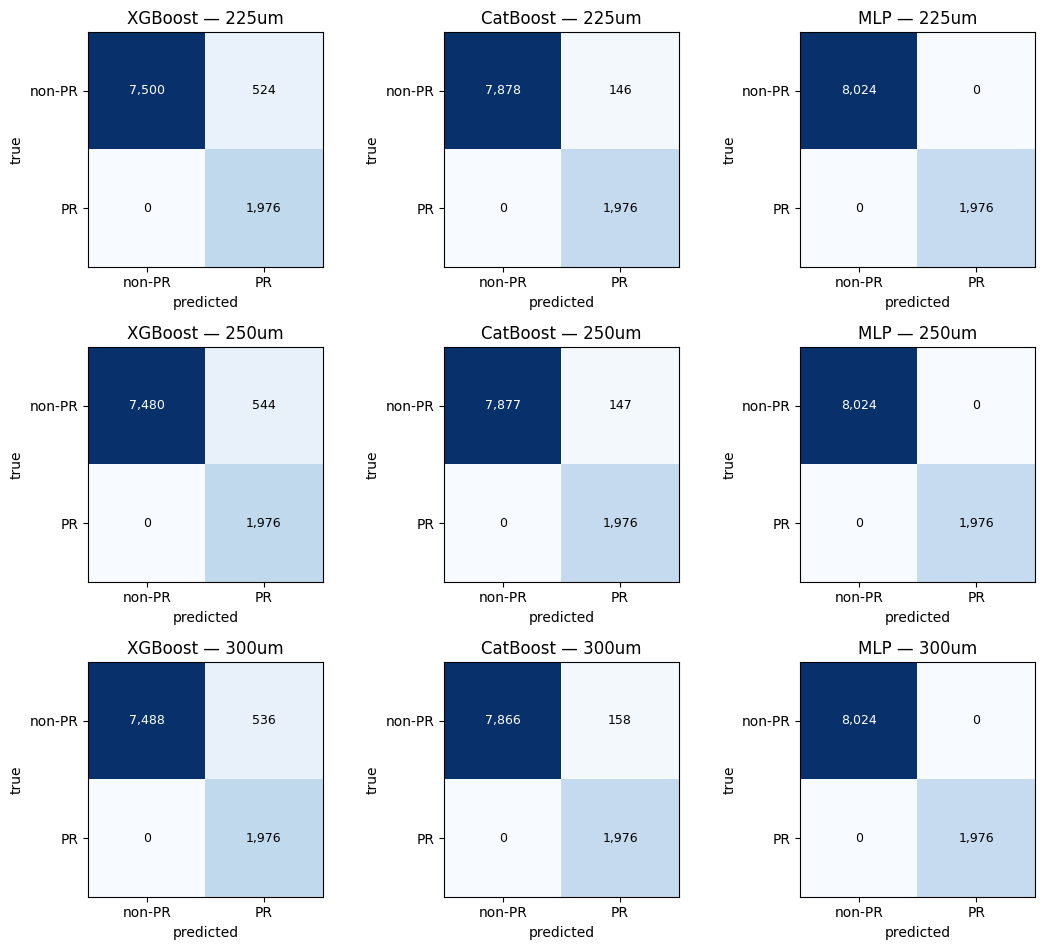

In [6]:
# Confusion matrices on simulated data (which way does each model err?)
fig, axes = plt.subplots(len(phantoms), 3, figsize=(11, 3.2*len(phantoms)))
if len(phantoms) == 1: axes = axes[None, :]
for i, (name, d) in enumerate(phantoms.items()):
    y = d["gt"].ravel().astype(int)
    X = extract_features(d["norm"], SCENARIO)
    preds = predict_proba(models, X)
    for j, model in enumerate(["XGBoost", "CatBoost", "MLP"]):
        cm = confusion_matrix(y, preds[model][1], labels=[0, 1])
        ax = axes[i, j]
        ax.imshow(cm, cmap="Blues")
        for (r, c), v in np.ndenumerate(cm):
            ax.text(c, r, f"{v:,}", ha="center", va="center",
                    color="white" if v > cm.max()/2 else "black", fontsize=9)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(["non-PR", "PR"]); ax.set_yticklabels(["non-PR", "PR"])
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.set_title(f"{model} — {name}")
plt.tight_layout(); plt.savefig(OUT_DIR / f"sim_confusion_{SCENARIO}.png", dpi=150); plt.show()


In [7]:
# XGBoost error direction summary
print("XGBoost error breakdown per phantom (is the bias systematic & one-directional?):")
for name, d in phantoms.items():
    y = d["gt"].ravel().astype(int)
    X = extract_features(d["norm"], SCENARIO)
    yhat = predict_proba(models, X)["XGBoost"][1]
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0,1]).ravel()
    n = len(y)
    print(f"  {name}: FP(non-PR->PR)={fp/n:6.3%}   FN(PR->non-PR)={fn/n:6.3%}   acc={(tp+tn)/n:.4f}")


XGBoost error breakdown per phantom (is the bias systematic & one-directional?):
  225um: FP(non-PR->PR)=5.240%   FN(PR->non-PR)=0.000%   acc=0.9476
  250um: FP(non-PR->PR)=5.440%   FN(PR->non-PR)=0.000%   acc=0.9456
  300um: FP(non-PR->PR)=5.360%   FN(PR->non-PR)=0.000%   acc=0.9464


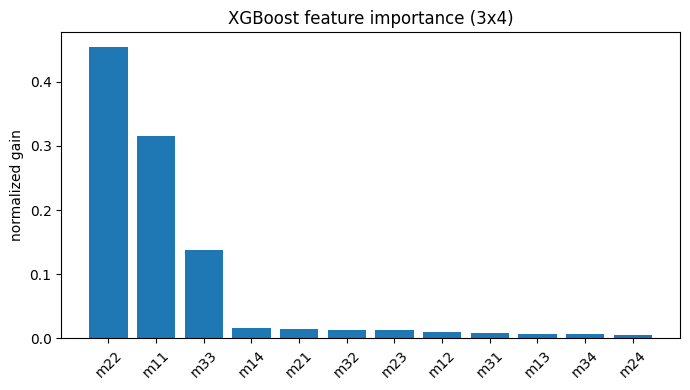

Top elements by gain: ['m22', 'm11', 'm33', 'm14', 'm21']

Interpretation: m11 is fixed at 1 after normalization; heavy reliance on a few
magnitude-carrying elements (vs. the elements that define the PR/coherency boundary)
is consistent with the 'keys on medium/tissue scale, not the PR rule' hypothesis.


In [8]:
# Feature importance (gain) for XGBoost vs the others' agreement
booster = models["XGBoost"]
n_feat = extract_features(next(iter(phantoms.values()))["norm"], SCENARIO).shape[1]
# map fN -> Mueller element label for current scenario
M44_idx = SCENARIOS[SCENARIO]["sel"](np.arange(16).reshape(4,4))  # which of 0..15 are used
flat_idx = M44_idx.ravel()
labels = [f"m{idx//4+1}{idx%4+1}" for idx in flat_idx]

gain = booster.get_score(importance_type="gain")
imp = np.array([gain.get(f"f{i}", 0.0) for i in range(n_feat)])
imp = imp / imp.sum() if imp.sum() else imp
order = np.argsort(imp)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(range(n_feat), imp[order])
plt.xticks(range(n_feat), [labels[i] for i in order], rotation=45)
plt.ylabel("normalized gain"); plt.title(f"XGBoost feature importance ({SCENARIO})")
plt.tight_layout(); plt.savefig(OUT_DIR / f"xgb_feature_importance_{SCENARIO}.png", dpi=150); plt.show()
print("Top elements by gain:", [labels[i] for i in order[:5]])
print("\nInterpretation: m11 is fixed at 1 after normalization; heavy reliance on a few")
print("magnitude-carrying elements (vs. the elements that define the PR/coherency boundary)")
print("is consistent with the 'keys on medium/tissue scale, not the PR rule' hypothesis.")


## 4. Reviewer #3 — Noise sensitivity (±5–20%)

We add zero-mean Gaussian noise to the **non-`m11`** elements of the M11-normalized matrix,
with standard deviation `p · m11` (i.e. relative to intensity), for `p ∈ {0, 5, 10, 15, 20}%`.
`m11` is held at 1. Labels stay the clean CCP ground truth — we are testing how the *learned
classifier's* output degrades, which is what matters for deployment. Several seeds give error
bars.


In [9]:
NOISE_LEVELS = [0.0, 0.05, 0.10, 0.15, 0.20]
N_SEEDS = 5

def add_noise_m11rel(norm_hw16, p, seed):
    g = np.random.default_rng(seed)
    out = norm_hw16.copy()
    noise = g.normal(0.0, p, size=out.shape)   # std = p (since m11 normalized to 1)
    out = out + noise
    out[:, :, 0] = norm_hw16[:, :, 0]           # keep m11 fixed
    return out

records = []
for name, d in phantoms.items():
    y = d["gt"].ravel().astype(int)
    for p in NOISE_LEVELS:
        for s in range(N_SEEDS):
            mm = d["norm"] if p == 0 else add_noise_m11rel(d["norm"], p, seed=1000*s + int(p*100))
            X = extract_features(mm, SCENARIO)
            preds = predict_proba(models, X)
            for model, (_, yhat) in preds.items():
                records.append(dict(phantom=name, model=model, noise=p, seed=s,
                                    f1=f1_score(y, yhat, zero_division=0),
                                    balanced_acc=balanced_accuracy_score(y, yhat)))
            if p == 0:   # deterministic; no need to repeat across seeds
                break
noise_df = pd.DataFrame(records)
noise_df.to_csv(OUT_DIR / f"noise_sensitivity_{SCENARIO}.csv", index=False)
print("Done. rows:", len(noise_df))


Done. rows: 189


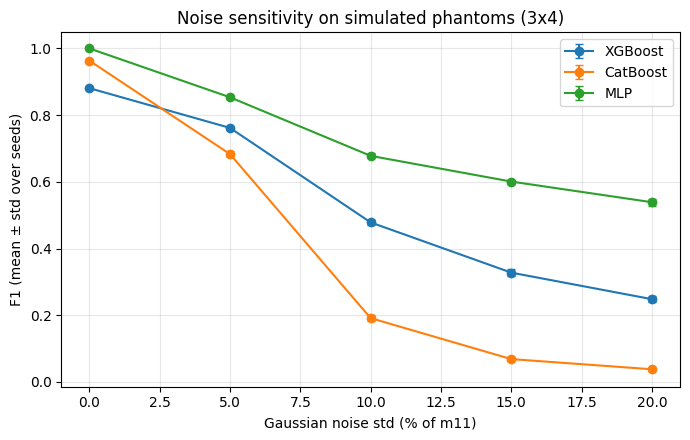

,model,noise,mean,std
0,CatBoost,0.00,0.9634,0.0016
1,CatBoost,0.05,0.6830,0.0099
2,CatBoost,0.10,0.1912,0.0083
3,CatBoost,0.15,0.0683,0.0054
4,CatBoost,0.20,0.0378,0.0041
5,MLP,0.00,1.0000,0.0000
6,MLP,0.05,0.8535,0.0045
7,MLP,0.10,0.6779,0.0078
8,MLP,0.15,0.6007,0.0060
9,MLP,0.20,0.5388,0.0107


In [10]:
# Plot F1 vs noise (mean +/- std over seeds), averaged across phantoms
agg = (noise_df.groupby(["model", "noise"])["f1"]
       .agg(["mean", "std"]).reset_index())
plt.figure(figsize=(7, 4.5))
for model in ["XGBoost", "CatBoost", "MLP"]:
    sub = agg[agg.model == model].sort_values("noise")
    plt.errorbar(sub.noise*100, sub["mean"], yerr=sub["std"].fillna(0),
                 marker="o", capsize=3, label=model)
plt.xlabel("Gaussian noise std (% of m11)"); plt.ylabel("F1 (mean ± std over seeds)")
plt.title(f"Noise sensitivity on simulated phantoms ({SCENARIO})")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT_DIR / f"noise_sensitivity_{SCENARIO}.png", dpi=150); plt.show()
agg.round(4)


## 5. Reviewer #3 — Confidence intervals (with the right caveat)

A binomial CI over millions of *pixels* is misleadingly tight because pixels within an image
are spatially correlated — the effective sample size is closer to the number of *images*. We
therefore report two things:

1. **Pixel bootstrap CI** (the naive interval) — and explicitly flag it as a lower bound on
   uncertainty.
2. **Across-phantom variability** (mean ± std over the three thicknesses) — closer to the
   honest uncertainty, and the template for the per-image CIs to report on the full real-tissue
   set.


In [11]:
def bootstrap_ci(y_true, y_pred, n_boot=1000, alpha=0.05, seed=0):
    g = np.random.default_rng(seed)
    n = len(y_true); stats = np.empty(n_boot)
    for b in range(n_boot):
        idx = g.integers(0, n, n)
        stats[b] = f1_score(y_true[idx], y_pred[idx], zero_division=0)
    lo, hi = np.quantile(stats, [alpha/2, 1-alpha/2])
    return lo, hi

# pooled across phantoms
rows = []
for model in ["XGBoost", "CatBoost", "MLP"]:
    yt, yp = [], []
    for name, d in phantoms.items():
        y = d["gt"].ravel().astype(int)
        X = extract_features(d["norm"], SCENARIO)
        yt.append(y); yp.append(predict_proba(models, X)[model][1])
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    lo, hi = bootstrap_ci(yt, yp)
    f1 = f1_score(yt, yp, zero_division=0)
    rows.append(dict(model=model, f1=f1, pixel_ci_lo=lo, pixel_ci_hi=hi))
ci_df = pd.DataFrame(rows)

# across-phantom variability (the honest interval)
perph = (noise_df[noise_df.noise == 0].groupby(["model"])["f1"]
         .agg(["mean", "std", "count"]).reset_index()
         .rename(columns={"mean": "f1_mean_over_phantoms", "std": "f1_std_over_phantoms"}))
ci_df = ci_df.merge(perph, on="model")
ci_df.to_csv(OUT_DIR / f"confidence_intervals_{SCENARIO}.csv", index=False)
print("Pixel bootstrap CI is a LOWER bound on uncertainty (pixels are spatially correlated).")
ci_df.round(4)


Pixel bootstrap CI is a LOWER bound on uncertainty (pixels are spatially correlated).


,model,f1,pixel_ci_lo,pixel_ci_hi,f1_mean_over_phantoms,f1_std_over_phantoms,count
0,XGBoost,0.8808,0.8752,0.8872,0.8808,0.0020,3
1,CatBoost,0.9634,0.9601,0.9668,0.9634,0.0016,3
2,MLP,1.0000,1.0000,1.0000,1.0000,0.0000,3


## 6. Reviewer #6 — Are misclassified pixels clustered or scattered?

We map the errors spatially and compute a **clustering ratio**: the fraction of error pixels
that have at least one adjacent (4-neighbour) error pixel, divided by what you'd expect if the
same number of errors were scattered uniformly at random. Ratio ≫ 1 ⇒ clustered (supports the
"confined to weak-signal regions" narrative); ratio ≈ 1 ⇒ random.


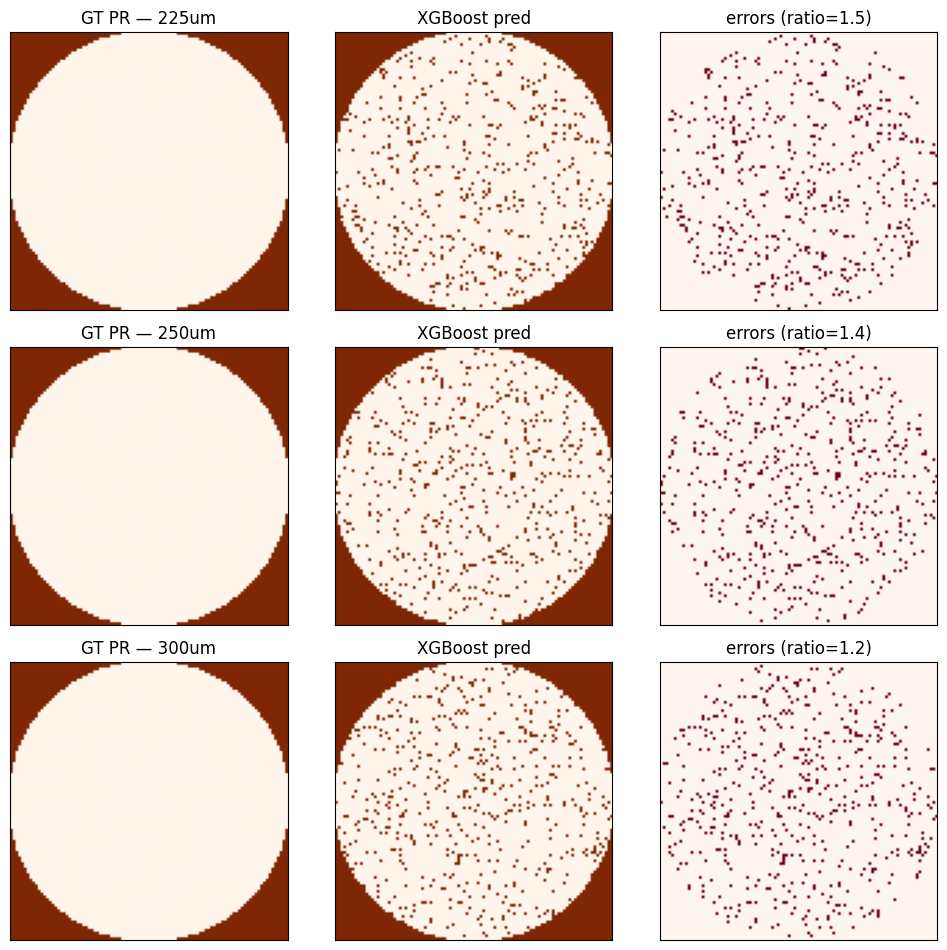

clustering_ratio >> 1  => errors cluster spatially (not random).


,phantom,model,n_errors,obs_adjacency,exp_adjacency,clustering_ratio
0,225um,XGBoost,524,0.298,0.192,1.548
1,250um,XGBoost,544,0.268,0.198,1.352
2,300um,XGBoost,536,0.243,0.196,1.238


In [12]:
def clustering_ratio(err_mask, n_rand=200, seed=0):
    """err_mask: (H,W) bool. Returns observed/expected adjacency fraction."""
    def adj_fraction(m):
        if m.sum() == 0: return 0.0
        nbr = np.zeros_like(m)
        nbr[:-1, :] |= m[1:, :]; nbr[1:, :] |= m[:-1, :]
        nbr[:, :-1] |= m[:, 1:]; nbr[:, 1:] |= m[:, :-1]
        return (m & nbr).sum() / m.sum()
    obs = adj_fraction(err_mask)
    H, W = err_mask.shape; k = int(err_mask.sum())
    if k == 0: return np.nan, obs, 0.0
    g = np.random.default_rng(seed); exps = []
    for _ in range(n_rand):
        flat = np.zeros(H*W, bool); flat[g.choice(H*W, k, replace=False)] = True
        exps.append(adj_fraction(flat.reshape(H, W)))
    exp = np.mean(exps)
    return (obs/exp if exp > 0 else np.nan), obs, exp

MODEL_FOR_MAPS = "XGBoost"   # the model with visible errors on simulated data
fig, axes = plt.subplots(len(phantoms), 3, figsize=(10, 3.2*len(phantoms)))
if len(phantoms) == 1: axes = axes[None, :]
clust_rows = []
for i, (name, d) in enumerate(phantoms.items()):
    y2d = d["gt"]
    H, W = y2d.shape
    X = extract_features(d["norm"], SCENARIO)
    yhat = predict_proba(models, X)[MODEL_FOR_MAPS][1].reshape(H, W)
    err = (yhat != y2d.astype(int))
    ratio, obs, exp = clustering_ratio(err)
    clust_rows.append(dict(phantom=name, model=MODEL_FOR_MAPS, n_errors=int(err.sum()),
                           obs_adjacency=obs, exp_adjacency=exp, clustering_ratio=ratio))
    axes[i,0].imshow(y2d, cmap="Oranges"); axes[i,0].set_title(f"GT PR — {name}")
    axes[i,1].imshow(yhat, cmap="Oranges"); axes[i,1].set_title(f"{MODEL_FOR_MAPS} pred")
    axes[i,2].imshow(err, cmap="Reds"); axes[i,2].set_title(f"errors (ratio={ratio:.1f})")
    for ax in axes[i]: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(OUT_DIR / f"error_clustering_sim_{SCENARIO}.png", dpi=150); plt.show()
clust_df = pd.DataFrame(clust_rows)
clust_df.to_csv(OUT_DIR / f"error_clustering_sim_{SCENARIO}.csv", index=False)
print("clustering_ratio >> 1  => errors cluster spatially (not random).")
clust_df.round(3)


### 6b. Real-tissue error clustering (auto-skips if data not mounted)

This repeats the clustering analysis on the held-out real-tissue samples (esp. the
thin-section skin where recall drops to 0.91). It needs the real test images; set
`REAL_TISSUE_GLOB` to your data location. If nothing is found the cell prints a notice and
skips.


In [13]:
# Point this at your real held-out tissue MM images (each (H,W,16) .npy).
REAL_TISSUE_DIRS = [
    file_paths.brain_test_path, file_paths.cervix_test_path, file_paths.afmmm_test_path,
]
real_files = []
for dd in REAL_TISSUE_DIRS:
    if Path(dd).exists():
        real_files += sorted(Path(dd).glob("*.npy"))

if not real_files:
    print("No real-tissue .npy test images found (external SSD not mounted?).")
    print("Searched:", [str(d) for d in REAL_TISSUE_DIRS])
    print("Skipping real-tissue clustering. Mount the data and re-run this cell.")
else:
    rows = []
    for f in real_files:
        arr = np.load(f)
        if arr.ndim == 2 and arr.shape[1] == 16:  # flattened
            print("skip (need H,W,16):", f.name); continue
        norm = normalize_by_m11(arr)
        y2d = ground_truth_pr(norm); H, W = y2d.shape
        X = extract_features(norm, SCENARIO)
        yhat = predict_proba(models, X)["XGBoost"][1].reshape(H, W)
        err = (yhat != y2d.astype(int))
        ratio, obs, exp = clustering_ratio(err)
        rows.append(dict(file=f.name, n_errors=int(err.sum()), clustering_ratio=ratio,
                         recall=recall_score(y2d.ravel().astype(int), yhat.ravel(), zero_division=0)))
    real_clust = pd.DataFrame(rows)
    real_clust.to_csv(OUT_DIR / f"error_clustering_real_{SCENARIO}.csv", index=False)
    display(real_clust.round(3))


No real-tissue .npy test images found (external SSD not mounted?).
Searched: ['/Users/chaechae/Desktop/EP_Code/partialPr/data/test/brain', '/Users/chaechae/Desktop/EP_Code/partialPr/data/test/cervix', '/Users/chaechae/Desktop/EP_Code/partialPr/data/test/afmmm']
Skipping real-tissue clustering. Mount the data and re-run this cell.


## 7. Reviewer #1 — Can PR be *uniquely determined* from the partial MM?

In general it cannot: two pixels with (near-)identical partial inputs can have different
full-`4×4` CCP labels. We quantify this **intrinsic determinability** empirically with a
nearest-neighbour purity test in partial-input space:

- For a sample of pixels, find each one's `k` nearest neighbours **in the partial-MM feature
  space** and measure the fraction whose CCP label *disagrees*.
- A non-zero disagreement rate is a direct, empirical estimate of the irreducible (Bayes) error
  — i.e. PR is not a deterministic function of the partial matrix, and any classifier (or
  closed form) is bounded by this. This reframes the contribution as *statistical
  predictability*, not equivalence, which is exactly the honest claim to make in the paper.


In [14]:
from sklearn.neighbors import NearestNeighbors

def neighbourhood_disagreement(X, y, k=8, sample=20000, seed=0):
    g = np.random.default_rng(seed)
    idx = g.choice(len(X), min(sample, len(X)), replace=False)
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)
    dist, nbr = nn.kneighbors(X[idx])
    nbr = nbr[:, 1:]                      # drop self
    disagree = (y[nbr] != y[idx][:, None]).mean(axis=1)
    return disagree.mean(), float(np.median(dist[:, 1]))

# pool all phantom pixels in partial-input space
Xall, yall = [], []
for d in phantoms.values():
    Xall.append(extract_features(d["norm"], SCENARIO))
    yall.append(d["gt"].ravel().astype(int))
Xall, yall = np.vstack(Xall), np.concatenate(yall)

dis, med_d = neighbourhood_disagreement(Xall, yall, k=8)
print(f"Mean label disagreement among 8 nearest neighbours in {SCENARIO} input space: {dis:.4f}")
print(f"(median NN distance: {med_d:.3g})")
print()
if dis < 1e-4:
    print("CONCLUSION: on this data PR is ~deterministically recoverable from the partial MM")
    print("(neighbourhoods are label-pure) -> empirical support that the learned map is well posed,")
    print("even though no closed form exists. State it as empirical, not a uniqueness guarantee.")
else:
    print("CONCLUSION: non-zero neighbourhood disagreement => PR is NOT a unique function of the")
    print(f"partial MM; intrinsic error floor ~{dis:.2%}. Frame the contribution as statistical")
    print("predictability of the 4x4-defined label, not 3x4<->4x4 equivalence.")


Mean label disagreement among 8 nearest neighbours in 3x4 input space: 0.0000
(median NN distance: 6.88e+05)

CONCLUSION: on this data PR is ~deterministically recoverable from the partial MM
(neighbourhoods are label-pure) -> empirical support that the learned map is well posed,
even though no closed form exists. State it as empirical, not a uniqueness guarantee.


## 8. Reviewer #5 — Real vs. simulated MM-element distributions (Wasserstein)

Per-element 1-D Wasserstein distance between simulated and real-tissue MM-element
distributions. Large distances on the elements that drive PR would indicate the phantoms are
out-of-distribution for the test. Requires real-tissue data; auto-skips otherwise.


In [15]:
if not real_files:
    print("Real-tissue data not available -> skipping Wasserstein comparison.")
    print("When mounted, this compares per-element distributions (real vs simulated).")
else:
    # simulated pool (normalized, all 16 elements)
    sim_pool = np.vstack([d["norm"].reshape(-1, 16) for d in phantoms.values()])
    real_pool = []
    for f in real_files:
        arr = np.load(f)
        if arr.ndim == 3 and arr.shape[-1] == 16:
            real_pool.append(normalize_by_m11(arr).reshape(-1, 16))
    real_pool = np.vstack(real_pool)
    labels16 = [f"m{r+1}{c+1}" for r in range(4) for c in range(4)]
    wd = [wasserstein_distance(sim_pool[:, i], real_pool[:, i]) for i in range(16)]
    wd_df = pd.DataFrame({"element": labels16, "wasserstein": wd}).sort_values("wasserstein", ascending=False)
    wd_df.to_csv(OUT_DIR / "wasserstein_real_vs_sim.csv", index=False)
    plt.figure(figsize=(8,4)); plt.bar(wd_df.element, wd_df.wasserstein)
    plt.xticks(rotation=45); plt.ylabel("Wasserstein (real vs sim)"); plt.tight_layout()
    plt.savefig(OUT_DIR / "wasserstein_real_vs_sim.png", dpi=150); plt.show()
    display(wd_df.round(4))


Real-tissue data not available -> skipping Wasserstein comparison.
When mounted, this compares per-element distributions (real vs simulated).


## 9. Summary for the rebuttal

In [16]:
print("="*70)
print("REVIEWER-RESPONSE ANALYSIS SUMMARY  (scenario:", SCENARIO, ")")
print("="*70)
print("\n#5  Class balance & honest metrics (simulated):")
print(sim_metrics.groupby("model")[["PR_fraction","accuracy","balanced_acc","mcc","f1"]]
      .mean().round(4).to_string())
print("\n#4  XGBoost top features (gain):", [labels[i] for i in order[:5]])
print("\n#3  Noise sensitivity (F1 @ 20% noise, mean over phantoms/seeds):")
print(noise_df[noise_df.noise==0.20].groupby("model")["f1"].mean().round(4).to_string())
print("\n#3  CIs:  see confidence_intervals_*.csv (pixel CI = lower bound; use across-image std)")
print("\n#6  Error clustering ratio (simulated, XGBoost):")
print(clust_df[["phantom","clustering_ratio"]].round(2).to_string(index=False))
print("\n#1  Neighbourhood label disagreement (intrinsic determinability):", f"{dis:.4f}")
print("\nAll figures/CSVs saved to:", OUT_DIR)


REVIEWER-RESPONSE ANALYSIS SUMMARY  (scenario: 3x4 )

#5  Class balance & honest metrics (simulated):
          PR_fraction  accuracy  balanced_acc     mcc      f1
model                                                        
CatBoost       0.1976    0.9850        0.9906  0.9549  0.9634
MLP            0.1976    1.0000        1.0000  1.0000  1.0000
XGBoost        0.1976    0.9465        0.9667  0.8571  0.8808

#4  XGBoost top features (gain): ['m22', 'm11', 'm33', 'm14', 'm21']

#3  Noise sensitivity (F1 @ 20% noise, mean over phantoms/seeds):
model
CatBoost    0.0378
MLP         0.5388
XGBoost     0.2481

#3  CIs:  see confidence_intervals_*.csv (pixel CI = lower bound; use across-image std)

#6  Error clustering ratio (simulated, XGBoost):
phantom  clustering_ratio
  225um              1.55
  250um              1.35
  300um              1.24

#1  Neighbourhood label disagreement (intrinsic determinability): 0.0000

All figures/CSVs saved to: /Users/chaechae/Desktop/EP_Code/partialPr/r